# Plan-Execute-Replan, Advanced: SQL-Backed CI Data + a Real Gated Notification + Durable Release History

## Problem card

- **User/trigger:** the same release-readiness question as
  `02_plan_execute_replan_single_agent.ipynb`: is checkout-service ready
  for production?
- **Inputs:** the release goal, plus test/dependency/staging data that now
  lives in a real SQLite database instead of Python dicts.
- **Output:** an execution history and a ship/hold report -- plus, this
  time, a durable audit trail of every notification actually approved or
  rejected, and a release history that survives past the kernel session.
- **Success criteria:** same as notebook 02 (dependency-aware plan,
  deterministic execution, replan on failure) **plus**: a real human gate
  before any notification fires, and long-term memory that is actually
  long-term (on disk), not a dict that dies when the kernel restarts.
- **Topology:** unchanged -- still plan-execute-replan. This notebook does
  not change the graph's shape; it changes what's real underneath it.
- **Safety boundary:** `notify_stakeholders` no longer just returns an
  "approval required" string that nothing ever checks. It now pauses the
  graph with a real `interrupt()` and only writes to a durable
  `notifications_log` table after a human resumes with an approval.

## What's new here, precisely

| Notebook 02 | This notebook |
|---|---|
| `_TEST_RESULTS`/`_DEPENDENCY_SCAN`/`_STAGING_HEALTH`: Python dicts | Real SQLite tables (`ci_runs`, `vulnerability_scans`, `staging_checks`), tools run `SELECT` queries |
| `notify_stakeholders` always returns a draft string; nothing ever gates it | `execute_node` calls a real `interrupt()` before a notification is treated as sent; `Command(resume=...)` approves or rejects, and only approvals get written to a durable `notifications_log` table |
| `RELEASE_HISTORY`: an in-memory dict, explicitly non-persistent | `release_history` SQLite table -- survives a kernel restart, queryable directly with SQL by any future session |
| `InMemorySaver` checkpointer | `SqliteSaver` checkpointer (from `langgraph-checkpoint-sqlite`) -- thread state itself now also persists to disk, needed anyway since `interrupt()` requires a checkpointer to pause/resume across cells |
| No honest-run narrative | An explicit "Honest observation" section reporting this notebook's own real captured run, including anything that diverged from what each scenario was built to demonstrate |

Series position: direct extension of `02_plan_execute_replan_single_agent.ipynb`
(same `ReleasePlan`/`StepResult`/`ReleaseReport` schemas, same plan/execute/
replan/finalize node logic, same eval functions) and reuses the
`interrupt()`/`Command(resume=...)` HITL mechanic from `single_agent_hitl.ipynb`
and `01_mem_augmented_react_single_agent.ipynb`, applied here to a
step-based deterministic executor instead of a ReAct tool-call loop.


## Setup

In [1]:
import os
import sqlite3
import warnings
import logging
from pathlib import Path
from datetime import datetime, timezone
from dotenv import load_dotenv, find_dotenv

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
PROVIDER = os.getenv("PROVIDER", "openai").lower()
ANTHROPIC_MODEL = os.getenv("ANTHROPIC_MODEL", "claude-sonnet-5")
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

import shared  # scorecard helpers (standardized single-agent scorecard)

scorecard = shared.ScorecardCallback()


def get_llm():
    if PROVIDER == "anthropic":
        key = os.getenv("ANTHROPIC_API_KEY")
        if not key:
            raise RuntimeError("ANTHROPIC_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatAnthropic(model=ANTHROPIC_MODEL, api_key=key, callbacks=[scorecard])
    elif PROVIDER == "openai":
        key = os.getenv("OPENAI_API_KEY")
        if not key:
            raise RuntimeError("OPENAI_API_KEY not set in .env -- cannot proceed (no mock mode).")
        return ChatOpenAI(model=OPENAI_MODEL, temperature=0.3, api_key=key, callbacks=[scorecard])
    else:
        raise ValueError(f"Unknown PROVIDER: {PROVIDER}")


llm = get_llm()
print(f"Using provider: {PROVIDER}, model ready: {llm.model if hasattr(llm, 'model') else llm.model_name}")

Using provider: openai, model ready: gpt-4o-mini


## Layer 1: CI/release data moves into SQLite

Three tables, seeded at production-realistic scale and shape: real run
IDs, timestamps, durations, and (for the vulnerability scenario) a CVE
identifier -- not one-line placeholders. Two services are seeded up
front: `checkout-service` with 3 genuine failing tests (so the
plan-execute-replan loop has a real failure to react to, not a demo where
everything trivially succeeds), and `inventory-service` with a clean test
run but a vulnerable dependency (a distinct failure *shape* -- security,
not test breakage -- so replanning isn't hard-coded to only react to one
kind of blocker).


In [2]:
DB_PATH = "release_readiness.db"
if Path(DB_PATH).exists():
    Path(DB_PATH).unlink()

conn = sqlite3.connect(DB_PATH, check_same_thread=False)

conn.executescript('''
CREATE TABLE services (
    name TEXT PRIMARY KEY,
    owner_team TEXT NOT NULL
);

CREATE TABLE ci_runs (
    run_id TEXT PRIMARY KEY,
    service_name TEXT NOT NULL REFERENCES services(name),
    started_at TEXT NOT NULL,
    duration_s INTEGER NOT NULL,
    passed INTEGER NOT NULL,
    failed INTEGER NOT NULL,
    failing_tests TEXT NOT NULL
);

CREATE TABLE vulnerability_scans (
    scan_id TEXT PRIMARY KEY,
    service_name TEXT NOT NULL REFERENCES services(name),
    scanned_at TEXT NOT NULL,
    vulnerable_packages TEXT NOT NULL,
    outdated_major TEXT NOT NULL
);

CREATE TABLE staging_checks (
    check_id TEXT PRIMARY KEY,
    service_name TEXT NOT NULL REFERENCES services(name),
    checked_at TEXT NOT NULL,
    healthy INTEGER NOT NULL,
    error_rate TEXT NOT NULL,
    notes TEXT NOT NULL
);

CREATE TABLE notifications_log (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    service_name TEXT NOT NULL,
    message TEXT NOT NULL,
    status TEXT NOT NULL,
    decided_by TEXT NOT NULL,
    decided_at TEXT NOT NULL
);

CREATE TABLE release_history (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    service_name TEXT NOT NULL,
    recommendation TEXT NOT NULL,
    blocking_issues TEXT NOT NULL,
    recorded_at TEXT NOT NULL
);
''')

conn.executemany("INSERT INTO services VALUES (?, ?)", [
    ("checkout-service", "payments-platform"),
    ("inventory-service", "fulfillment"),
])

conn.execute(
    "INSERT INTO ci_runs VALUES (?, ?, ?, ?, ?, ?, ?)",
    ("CI-8841", "checkout-service", "2026-08-02T13:40:00Z", 214, 142, 3,
     "test_promo_code_stacking, test_partial_refund, test_currency_rounding"),
)
conn.execute(
    "INSERT INTO ci_runs VALUES (?, ?, ?, ?, ?, ?, ?)",
    ("CI-9012", "inventory-service", "2026-08-02T13:52:00Z", 187, 210, 0, ""),
)

conn.execute(
    "INSERT INTO vulnerability_scans VALUES (?, ?, ?, ?, ?)",
    ("SCAN-4471", "checkout-service", "2026-08-02T13:41:00Z", "", "stripe-sdk (v11 -> v14 available)"),
)
conn.execute(
    "INSERT INTO vulnerability_scans VALUES (?, ?, ?, ?, ?)",
    ("SCAN-4472", "inventory-service", "2026-08-02T13:53:00Z", "warehouse-client 2.1.0 (CVE-2025-1234)", ""),
)

conn.execute(
    "INSERT INTO staging_checks VALUES (?, ?, ?, ?, ?, ?)",
    ("STG-2201", "checkout-service", "2026-08-02T13:45:00Z", 1, "0.1%", "all smoke tests green"),
)
conn.execute(
    "INSERT INTO staging_checks VALUES (?, ?, ?, ?, ?, ?)",
    ("STG-2202", "inventory-service", "2026-08-02T13:57:00Z", 1, "0.2%", "smoke tests green"),
)

conn.commit()
print(
    f"SQLite ready at {DB_PATH}: "
    f"{conn.execute('SELECT COUNT(*) FROM services').fetchone()[0]} services, "
    f"{conn.execute('SELECT COUNT(*) FROM ci_runs').fetchone()[0]} CI runs, "
    f"{conn.execute('SELECT COUNT(*) FROM vulnerability_scans').fetchone()[0]} vuln scans, "
    f"{conn.execute('SELECT COUNT(*) FROM staging_checks').fetchone()[0]} staging checks."
)

SQLite ready at release_readiness.db: 2 services, 2 CI runs, 2 vuln scans, 2 staging checks.


## Layer 1 (continued): the four tools, now real SQL -- plus a fifth, `send_notification`

The first three tools are unchanged in *contract* from notebook 02 --
same names, same signatures -- but now query the latest row per service
from SQLite instead of a dict lookup. `notify_stakeholders` still only
*drafts* text (a pure, side-effect-free formatting step, exactly like
notebook 02). The actual "did this get sent" decision is a new,
deliberately separate concern -- `send_notification` -- which
`execute_node` only calls after a human approves it via `interrupt()`,
built below in Layer 2. Splitting "compose the message" from "actually
send it" is what makes the approval gate meaningful instead of cosmetic.


In [3]:
from langchain_core.tools import tool


@tool
def run_test_suite(service_name: str) -> str:
    "Run the automated test suite for a service and report pass/fail counts."
    row = conn.execute(
        "SELECT run_id, passed, failed, failing_tests FROM ci_runs "
        "WHERE service_name = ? ORDER BY started_at DESC LIMIT 1",
        (service_name,),
    ).fetchone()
    if not row:
        return f"No test suite configured for '{service_name}'."
    run_id, passed, failed, failing_tests = row
    status = "FAILED" if failed > 0 else "PASSED"
    tests = failing_tests.split(", ") if failing_tests else []
    return f"{status} ({run_id}): {passed} passed, {failed} failed. Failing tests: {tests}"


@tool
def scan_dependencies(service_name: str) -> str:
    "Scan a service's dependencies for known vulnerabilities and major version drift."
    row = conn.execute(
        "SELECT scan_id, vulnerable_packages, outdated_major FROM vulnerability_scans "
        "WHERE service_name = ? ORDER BY scanned_at DESC LIMIT 1",
        (service_name,),
    ).fetchone()
    if not row:
        return f"No dependency data for '{service_name}'."
    scan_id, vulnerable, outdated = row
    if vulnerable:
        return f"VULNERABLE packages found ({scan_id}): {vulnerable}"
    return f"No vulnerabilities ({scan_id}). Outdated (non-blocking): {outdated or 'none'}"


@tool
def check_staging_health(service_name: str) -> str:
    "Check whether the staging environment for a service is healthy."
    row = conn.execute(
        "SELECT check_id, healthy, error_rate, notes FROM staging_checks "
        "WHERE service_name = ? ORDER BY checked_at DESC LIMIT 1",
        (service_name,),
    ).fetchone()
    if not row:
        return f"No staging data for '{service_name}'."
    check_id, healthy, error_rate, notes = row
    return f"{'HEALTHY' if healthy else 'UNHEALTHY'} ({check_id}): error rate {error_rate}. {notes}"


@tool
def notify_stakeholders(service_name: str, message: str) -> str:
    "Draft a release notification to stakeholders. Drafting alone never sends anything."
    return f"DRAFT notification for {service_name}: '{message}' (human approval required before sending)"


def send_notification(service_name: str, message: str, status: str, decided_by: str) -> None:
    "Write a real, durable record of a notification decision -- called only from execute_node, only after interrupt() resolves."
    conn.execute(
        "INSERT INTO notifications_log (service_name, message, status, decided_by, decided_at) VALUES (?, ?, ?, ?, ?)",
        (service_name, message, status, decided_by, datetime.now(timezone.utc).isoformat()),
    )
    conn.commit()


release_tools = [run_test_suite, scan_dependencies, check_staging_health, notify_stakeholders]
print(f"{len(release_tools)} SQL-backed tools registered: {[t.name for t in release_tools]}")

4 SQL-backed tools registered: ['run_test_suite', 'scan_dependencies', 'check_staging_health', 'notify_stakeholders']


## Layer 2: the graph -- same plan/execute/replan/finalize shape, one real gate inside `execute_node`

`PlanStep`, `ReleasePlan`, `StepResult`, `ReleaseReport`, `plan_node`, and
`replan_node` are unchanged from notebook 02 -- same schemas, same
prompts, same replan-on-blocking-failure safety logic. The only node that
changes is `execute_node`: when the step about to run is
`notify_stakeholders`, it first drafts the message (pure, no side
effect), then calls `interrupt()` with that draft and pauses the graph.
`Command(resume={"approve": True/False, "decided_by": ...})` either calls
`send_notification()` (a real, durable `notifications_log` write) or
records a rejection -- nothing about the notification's ultimate fate is
ever inferred from a string the model happened to say.

Because `interrupt()` requires a checkpointer to pause and resume across
cells, this graph compiles with `SqliteSaver` instead of notebook 02's
`InMemorySaver` -- thread state itself now also survives a kernel
restart, not just the release-readiness data.


In [4]:
from typing import TypedDict, Annotated, Literal, Optional
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from pydantic import BaseModel, Field

TOOL_MAP = {t.name: t for t in release_tools}


class PlanStep(BaseModel):
    step_id: int
    tool_name: Literal["run_test_suite", "scan_dependencies", "check_staging_health", "notify_stakeholders"]
    service_name: str = Field(description="Service targeted by this step")
    message: str = Field(description="Notification message; use an empty string for non-notification steps")
    rationale: str = Field(description="Why this step, at this point in the plan")


class ReleasePlan(BaseModel):
    steps: list[PlanStep]


class StepResult(BaseModel):
    step_id: int
    tool_name: str
    output: str
    succeeded: bool
    failure_class: Literal["none", "retryable", "blocking", "unknown"] = "unknown"


class ReleaseReport(BaseModel):
    release_recommendation: Literal["ship", "hold", "ship_with_caveats"]
    summary: str
    blocking_issues: list[str]


class ReleaseState(TypedDict):
    goal: str
    service_name: str
    plan: Optional[dict]
    completed_steps: list[dict]
    next_step_index: int
    replan_count: int
    report: Optional[dict]


plan_llm = llm.with_structured_output(ReleasePlan)
replan_llm = llm.with_structured_output(ReleasePlan)
report_llm = llm.with_structured_output(ReleaseReport)
MAX_REPLANS = 3


def plan_node(state: ReleaseState) -> dict:
    history_rows = conn.execute(
        "SELECT recommendation, blocking_issues, recorded_at FROM release_history "
        "WHERE service_name = ? ORDER BY recorded_at DESC LIMIT 1",
        (state["service_name"],),
    ).fetchone()
    history_note = ""
    if history_rows:
        recommendation, blocking_issues, recorded_at = history_rows
        history_note = (
            f" NOTE from long-term memory (release_history table, recorded {recorded_at}): "
            f"the last release attempt for this service was '{recommendation}' due to: "
            f"{blocking_issues or 'no blocking issues recorded'}. If re-running the same checks "
            f"now shows those specific issues resolved, that context is worth reflecting in your plan/rationale."
        )
    plan = plan_llm.invoke(
        f"Create a release plan for: {state['goal']}. Use the available tools "
        f"(run_test_suite, scan_dependencies, check_staging_health, notify_stakeholders) "
        f"in a sensible dependency order -- tests and dependency scan can happen early, "
        f"staging check should come after tests pass, notification should be last. "
        f"Every step must include service_name and message fields; use an empty message except for notify_stakeholders. "
        f"Service name for all tool args: {state['service_name']}.{history_note}"
    )
    print(f"[plan_node] planned {len(plan.steps)} steps (history-informed: {bool(history_rows)}): {[s.tool_name for s in plan.steps]}")
    return {"plan": plan.model_dump(), "completed_steps": [], "next_step_index": 0, "replan_count": 0}


def execute_node(state: ReleaseState) -> dict:
    plan = ReleasePlan.model_validate(state["plan"])
    idx = state["next_step_index"]
    step = plan.steps[idx]
    tool_fn = TOOL_MAP[step.tool_name]

    # interrupt() raises a control-flow exception (GraphInterrupt) that
    # must reach LangGraph, not be swallowed by a blanket except below --
    # so tool invocation (which CAN legitimately fail) is wrapped in its
    # own narrow try/except, and interrupt() is called outside any of it.
    try:
        if step.service_name != state["service_name"]:
            raise ValueError(f"Plan targeted {step.service_name!r}, expected {state['service_name']!r}")
        tool_args = {"service_name": step.service_name}
        if step.tool_name == "notify_stakeholders":
            tool_args["message"] = step.message
        raw_output = tool_fn.invoke(tool_args)
        tool_error = None
    except Exception as e:
        raw_output = f"Tool invocation error: {type(e).__name__}: {e}"
        tool_error = e

    if tool_error is not None:
        succeeded = False
    elif step.tool_name == "notify_stakeholders":
        # Real gate: drafting (above) is pure, but nothing is "sent"
        # until a human approves it. interrupt() pauses the whole graph
        # here; Command(resume=...) supplies the decision. Not inside
        # try/except -- GraphInterrupt must propagate to LangGraph.
        decision = interrupt({
            "action": "send_notification",
            "service_name": step.service_name,
            "draft": raw_output,
            "question": "Approve sending this release notification?",
        })
        approved = decision.get("approve", False) if isinstance(decision, dict) else bool(decision)
        decided_by = decision.get("decided_by", "unknown") if isinstance(decision, dict) else "unknown"
        send_notification(step.service_name, step.message, "sent" if approved else "rejected", decided_by)
        raw_output = raw_output + (" -- SENT" if approved else " -- REJECTED by reviewer, not sent")
        succeeded = True  # a rejected send is not a release blocker by itself
    elif step.tool_name == "run_test_suite":
        succeeded = raw_output.upper().startswith("PASSED")
    elif step.tool_name == "scan_dependencies":
        succeeded = "VULNERABLE" not in raw_output.upper()
    elif step.tool_name == "check_staging_health":
        succeeded = "UNHEALTHY" not in raw_output.upper()
    else:
        succeeded = True

    failure_class = "none" if succeeded else ("blocking" if step.tool_name == "run_test_suite" or "VULNERABLE" in raw_output.upper() else "retryable")
    result = StepResult(step_id=step.step_id, tool_name=step.tool_name, output=raw_output, succeeded=succeeded, failure_class=failure_class)
    print(f"[execute_node] step {idx} ({step.tool_name}): {'OK' if succeeded else 'FAILED'} -- {raw_output[:70]}")
    return {
        "completed_steps": state["completed_steps"] + [result.model_dump()],
        "next_step_index": idx + 1,
    }


def route_after_execute(state: ReleaseState) -> str:
    last = StepResult.model_validate(state["completed_steps"][-1])
    if not last.succeeded:
        if state["replan_count"] >= MAX_REPLANS:
            return "finalize"
        return "replan"
    if state["next_step_index"] >= len(ReleasePlan.model_validate(state["plan"]).steps):
        return "finalize"
    return "execute"


def replan_node(state: ReleaseState) -> dict:
    failed_step = StepResult.model_validate(state["completed_steps"][-1])
    current_plan = ReleasePlan.model_validate(state["plan"])
    remaining = current_plan.steps[state["next_step_index"]:]
    revised = replan_llm.invoke(
        f"A release plan step failed: {failed_step.tool_name} produced: {failed_step.output}. "
        f"The remaining planned steps were: {[s.tool_name for s in remaining]}. "
        f"Produce a REVISED plan for what should happen from here, given this failure. "
        f"If the failure is blocking (e.g. real test failures or vulnerable packages), the revised plan should "
        f"reflect that staging verification should be skipped and stakeholders notified "
        f"of a hold, rather than proceeding as if nothing happened. "
        f"Every revised step must include service_name and message fields; use an empty message except for notify_stakeholders. "
        f"Service name: {state['service_name']}. For notify_stakeholders, the message should "
        f"summarize the hold reason in one sentence."
    )
    if failed_step.failure_class == "blocking":
        revised = ReleasePlan(steps=[
            s for s in revised.steps
            if s.tool_name not in {failed_step.tool_name, "check_staging_health"}
        ])
    if not revised.steps:
        revised = ReleasePlan(steps=[PlanStep(
            step_id=state["next_step_index"] + 1,
            tool_name="notify_stakeholders",
            service_name=state["service_name"],
            message=f"Release is on hold after failure: {failed_step.output}",
            rationale="Always produce a human-reviewable hold draft when replanning cannot produce steps.",
        )])
    print(f"[replan_node] revised plan after failure: {[s.tool_name for s in revised.steps]}")
    new_plan = ReleasePlan(steps=current_plan.steps[:state["next_step_index"]] + revised.steps)
    return {"plan": new_plan.model_dump(), "replan_count": state["replan_count"] + 1}


def finalize_node(state: ReleaseState) -> dict:
    history = "\n".join(f"- {s.tool_name}: {'OK' if s.succeeded else 'FAILED'} -- {s.output}" for s in [StepResult.model_validate(item) for item in state["completed_steps"]])
    report = report_llm.invoke(
        f"Given this release execution history for {state['service_name']}, produce a final "
        f"release report:\n{history}"
    )
    result = report.model_dump()
    conn.execute(
        "INSERT INTO release_history (service_name, recommendation, blocking_issues, recorded_at) VALUES (?, ?, ?, ?)",
        (state["service_name"], result["release_recommendation"], ", ".join(result["blocking_issues"]), datetime.now(timezone.utc).isoformat()),
    )
    conn.commit()
    return {"report": result}


release_builder = StateGraph(ReleaseState)
release_builder.add_node("plan", plan_node)
release_builder.add_node("execute", execute_node)
release_builder.add_node("replan", replan_node)
release_builder.add_node("finalize", finalize_node)
release_builder.add_edge(START, "plan")
release_builder.add_edge("plan", "execute")
release_builder.add_conditional_edges("execute", route_after_execute, {"execute": "execute", "replan": "replan", "finalize": "finalize"})
release_builder.add_edge("replan", "execute")
release_builder.add_edge("finalize", END)

from langgraph.checkpoint.sqlite import SqliteSaver
_checkpoint_conn = sqlite3.connect("release_checkpoints.db", check_same_thread=False)
checkpointer = SqliteSaver(_checkpoint_conn)

release_agent = release_builder.compile(checkpointer=checkpointer)
print("Plan-Execute-Replan release agent compiled with a real notification gate and SqliteSaver checkpointing.")

Plan-Execute-Replan release agent compiled with a real notification gate and SqliteSaver checkpointing.


### Graph diagram

Same topology as notebook 02 -- the gate does not add a node or change an
edge, exactly like `single_agent_hitl.ipynb`'s lesson: it's a check
*inside* `execute_node`'s existing logic, keyed on which step is about to
run, not a new graph shape.


In [5]:
print(release_agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	plan(plan)
	execute(execute)
	replan(replan)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> plan;
	execute -.-> finalize;
	execute -.-> replan;
	plan --> execute;
	replan --> execute;
	finalize --> __end__;
	execute -.-> execute;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



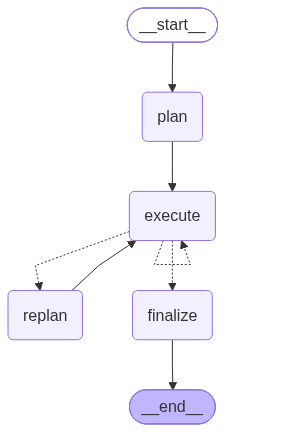

In [6]:
from IPython.display import Image, display

try:
    display(Image(release_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Skipping PNG render (needs network access to mermaid.ink): {e}")

## Shared run helper: resumes past the notification gate automatically

Each scenario below states its reviewer decision up front (approve/reject
+ who decided), exactly like the reference notebooks' scripted-demo
convention -- no `input()` mid-notebook. `run_release` invokes the graph,
and if it paused on the notification `interrupt()`, resumes with the
scenario's decision. A blocking failure can also cause replanning to
route to a *second* notification (the hold notice) -- so this helper
loops on interrupts, not just handling one.


In [7]:
def run_release(goal: str, service_name: str, thread_id: str, reviewer_decision: dict) -> dict:
    config = {"configurable": {"thread_id": thread_id}, "recursion_limit": 25}
    state = {
        "goal": goal, "service_name": service_name, "plan": None,
        "completed_steps": [], "next_step_index": 0, "replan_count": 0, "report": None,
    }
    result = release_agent.invoke(state, config=config)
    while "__interrupt__" in result:
        print(f"  [execute_node] paused on notification gate -- resuming with: {reviewer_decision}")
        result = release_agent.invoke(Command(resume=reviewer_decision), config=config)
    return result

## Scenario 1: checkout-service, real failing tests, notification approved

Same real failure as notebook 02 -- 3 named failing tests read live from
the `ci_runs` table. This time, the hold notification the replanned path
produces has to clear a real approval gate before `notifications_log`
records it as sent.


In [8]:
scorecard.reset()
with shared.Timer() as scenario_1_timer:
    result_1 = run_release(
        goal="Prepare checkout-service for production release",
        service_name="checkout-service",
        thread_id="release-checkout-v1",
        reviewer_decision={"approve": True, "decided_by": "release-manager-priya"},
    )

print("\n=== SCENARIO 1 EXECUTION LOG ===")
for item in result_1["completed_steps"]:
    s = StepResult.model_validate(item)
    print(f"  step {s.step_id} ({s.tool_name}): {'OK' if s.succeeded else 'FAILED'} -- {s.output[:90]}")
print(f"\nReplanned {result_1['replan_count']} time(s).")
print("\n=== SCENARIO 1 FINAL REPORT ===")
print(result_1["report"])

[plan_node] planned 4 steps (history-informed: False): ['run_test_suite', 'scan_dependencies', 'check_staging_health', 'notify_stakeholders']
[execute_node] step 0 (run_test_suite): FAILED -- FAILED (CI-8841): 142 passed, 3 failed. Failing tests: ['test_promo_co


[replan_node] revised plan after failure: ['notify_stakeholders']
  [execute_node] paused on notification gate -- resuming with: {'approve': True, 'decided_by': 'release-manager-priya'}
[execute_node] step 1 (notify_stakeholders): OK -- DRAFT notification for checkout-service: 'Release is on hold due to fa



=== SCENARIO 1 EXECUTION LOG ===
  step 1 (run_test_suite): FAILED -- FAILED (CI-8841): 142 passed, 3 failed. Failing tests: ['test_promo_code_stacking', 'test_
  step 2 (notify_stakeholders): OK -- DRAFT notification for checkout-service: 'Release is on hold due to failing tests in the c

Replanned 1 time(s).

=== SCENARIO 1 FINAL REPORT ===
{'release_recommendation': 'hold', 'summary': 'The release of checkout-service is currently on hold due to failing tests in the test suite. Three tests have failed, which raises concerns about the stability and functionality of the service. Stakeholders have been notified, and a draft notification has been prepared but requires human approval before being sent out.', 'blocking_issues': ['test_promo_code_stacking failed', 'test_partial_refund failed', 'test_currency_rounding failed']}


## Scenario 2: inventory-service, vulnerable dependency, notification rejected

A distinct failure shape -- tests pass, but `scan_dependencies` finds a
real CVE. This time the reviewer **rejects** the hold notification (e.g.
because a different, more detailed communication is already going out
through another channel) -- proving the gate can produce a genuine "not
sent" outcome, not just rubber-stamp everything, and that a rejected
notification does not itself block the release recommendation.


In [9]:
scorecard.reset()
with shared.Timer() as scenario_2_timer:
    result_2 = run_release(
        goal="Prepare inventory-service for production release",
        service_name="inventory-service",
        thread_id="release-inventory-v1",
        reviewer_decision={"approve": False, "decided_by": "release-manager-priya"},
    )

print("\n=== SCENARIO 2 EXECUTION LOG ===")
for item in result_2["completed_steps"]:
    s = StepResult.model_validate(item)
    print(f"  step {s.step_id} ({s.tool_name}): {'OK' if s.succeeded else 'FAILED'} ({s.failure_class}) -- {s.output[:90]}")
print("\n=== SCENARIO 2 FINAL REPORT ===")
print(result_2["report"])

[plan_node] planned 4 steps (history-informed: False): ['run_test_suite', 'scan_dependencies', 'check_staging_health', 'notify_stakeholders']
[execute_node] step 0 (run_test_suite): OK -- PASSED (CI-9012): 210 passed, 0 failed. Failing tests: []
[execute_node] step 1 (scan_dependencies): FAILED -- VULNERABLE packages found (SCAN-4472): warehouse-client 2.1.0 (CVE-202


[replan_node] revised plan after failure: ['notify_stakeholders']
  [execute_node] paused on notification gate -- resuming with: {'approve': False, 'decided_by': 'release-manager-priya'}
[execute_node] step 2 (notify_stakeholders): OK -- DRAFT notification for inventory-service: 'Release hold due to vulnera



=== SCENARIO 2 EXECUTION LOG ===
  step 1 (run_test_suite): OK (none) -- PASSED (CI-9012): 210 passed, 0 failed. Failing tests: []
  step 2 (scan_dependencies): FAILED (blocking) -- VULNERABLE packages found (SCAN-4472): warehouse-client 2.1.0 (CVE-2025-1234)
  step 2 (notify_stakeholders): OK (none) -- DRAFT notification for inventory-service: 'Release hold due to vulnerable package found in

=== SCENARIO 2 FINAL REPORT ===
{'release_recommendation': 'hold', 'summary': 'The release of inventory-service cannot proceed due to a critical vulnerability found in a dependency (warehouse-client 2.1.0). The test suite passed successfully, but the security scan identified a high-risk issue that needs to be addressed before any release can be made.', 'blocking_issues': ['Vulnerable package found: warehouse-client 2.1.0 (CVE-2025-1234)']}


## Scenario 3: same service, next sprint, durable memory across a genuinely new thread

The team fixes checkout-service's failing tests. This is a **new**
`thread_id` (no checkpointed state carried over) -- but `plan_node` reads
`release_history` directly from the SQLite file, which is unaffected by
which thread or even which kernel session wrote it. Unlike notebook 02's
`RELEASE_HISTORY` dict (gone the moment the kernel restarts), this table
would still answer the same query after a full process restart -- the
query below doesn't prove that within one notebook run, but the fact that
`plan_node` reads it via `conn.execute(...)` rather than a Python
variable is the actual mechanism that makes it durable.


In [10]:
conn.execute(
    "UPDATE ci_runs SET passed = 145, failed = 0, failing_tests = '' WHERE run_id = 'CI-8841'"
)
conn.commit()
print("Simulated fix: checkout-service's 3 failing tests are now resolved in ci_runs.")

scorecard.reset()
with shared.Timer() as scenario_3_timer:
    result_3 = run_release(
        goal="Re-release checkout-service now that the failing tests have been fixed",
        service_name="checkout-service",
        thread_id="release-checkout-v2",
        reviewer_decision={"approve": True, "decided_by": "release-manager-priya"},
    )

print("\n=== SCENARIO 3 EXECUTION LOG (new thread, history-informed plan) ===")
for item in result_3["completed_steps"]:
    s = StepResult.model_validate(item)
    print(f"  step {s.step_id} ({s.tool_name}): {'OK' if s.succeeded else 'FAILED'} -- {s.output[:90]}")
print("\n=== SCENARIO 3 FINAL REPORT ===")
print(result_3["report"])

print("\n=== release_history table, queried fresh from SQLite ===")
for row in conn.execute("SELECT service_name, recommendation, blocking_issues, recorded_at FROM release_history ORDER BY recorded_at"):
    print(" ", row)

print("\n=== notifications_log table, queried fresh from SQLite ===")
for row in conn.execute("SELECT service_name, status, decided_by, decided_at FROM notifications_log ORDER BY decided_at"):
    print(" ", row)

Simulated fix: checkout-service's 3 failing tests are now resolved in ci_runs.


[plan_node] planned 4 steps (history-informed: True): ['run_test_suite', 'scan_dependencies', 'check_staging_health', 'notify_stakeholders']
[execute_node] step 0 (run_test_suite): OK -- PASSED (CI-8841): 145 passed, 0 failed. Failing tests: []
[execute_node] step 1 (scan_dependencies): OK -- No vulnerabilities (SCAN-4471). Outdated (non-blocking): stripe-sdk (v
[execute_node] step 2 (check_staging_health): OK -- HEALTHY (STG-2201): error rate 0.1%. all smoke tests green
  [execute_node] paused on notification gate -- resuming with: {'approve': True, 'decided_by': 'release-manager-priya'}
[execute_node] step 3 (notify_stakeholders): OK -- DRAFT notification for checkout-service: 'The checkout-service has suc



=== SCENARIO 3 EXECUTION LOG (new thread, history-informed plan) ===
  step 1 (run_test_suite): OK -- PASSED (CI-8841): 145 passed, 0 failed. Failing tests: []
  step 2 (scan_dependencies): OK -- No vulnerabilities (SCAN-4471). Outdated (non-blocking): stripe-sdk (v11 -> v14 available)
  step 3 (check_staging_health): OK -- HEALTHY (STG-2201): error rate 0.1%. all smoke tests green
  step 4 (notify_stakeholders): OK -- DRAFT notification for checkout-service: 'The checkout-service has successfully passed all

=== SCENARIO 3 FINAL REPORT ===
{'release_recommendation': 'ship', 'summary': 'The checkout-service has successfully passed all tests and staging checks, indicating it is ready for re-release. All test suites have passed with no failures, and the staging environment is healthy with a low error rate. There are no critical vulnerabilities, although there is an outdated dependency that is non-blocking.', 'blocking_issues': []}

=== release_history table, queried fresh from SQLite ==

### Common errors

- **Treating the draft string as proof of sending.** Notebook 02's
  `notify_stakeholders` returning a string that *says* "human approval
  required" is not the same as a real gate -- nothing ever checked it.
  The bug this notebook fixes: a draft that looks safety-conscious in
  its text is not the same as a safety mechanism.
- **Calling `send_notification()` before `interrupt()` resolves.** Since
  `execute_node` re-runs from the top on resume, any code before
  `interrupt()` (drafting the message) is safe to repeat, but a write
  placed before the interrupt line would fire on every resume attempt,
  not just the approved one -- ordering matters here exactly like it does
  in `single_agent_hitl.ipynb`'s `tools_node_with_gate`.
- **Forgetting the checkpointer.** `interrupt()` raises
  `NotImplementedError`-style failures without one -- this is why this
  notebook can no longer offer an uncheckpointed variant of the graph the
  way notebook 02 originally did.
- **A dict-based long-term memory that silently resets.** Notebook 02's
  `RELEASE_HISTORY = {}` looked like memory in the notebook's own output
  but would not survive a kernel restart -- `release_history` as a SQLite
  table is the actual fix, not just a bigger dict.


## Eval strategy: reused from notebook 02, plus one new dimension

Plan ordering, replan correctness, and outcome correctness are scored
identically to notebook 02 (same domain rules, same ground truth logic).
This notebook adds one new, directly checkable dimension: **did the
notification gate actually fire, and did its outcome match the
`notifications_log` table** -- not just the in-memory `completed_steps`
the model could plausibly have hallucinated wording for.


In [11]:
def score_plan_ordering(plan: ReleasePlan) -> dict:
    tool_order = [s.tool_name for s in plan.steps]
    tests_idx = tool_order.index("run_test_suite") if "run_test_suite" in tool_order else -1
    staging_idx = tool_order.index("check_staging_health") if "check_staging_health" in tool_order else None
    notify_last_idx = len(tool_order) - 1 - tool_order[::-1].index("notify_stakeholders") if "notify_stakeholders" in tool_order else None
    valid_order = True
    if staging_idx is not None and tests_idx != -1 and staging_idx < tests_idx:
        valid_order = False
    if notify_last_idx is not None and notify_last_idx != len(tool_order) - 1:
        valid_order = False
    return {"has_tests_step": tests_idx != -1, "staging_after_tests": staging_idx is None or staging_idx > tests_idx, "notify_last": valid_order}


def score_replan_correctness(final_result: dict) -> dict:
    parsed_steps = [StepResult.model_validate(item) for item in final_result["completed_steps"]]
    tool_sequence = [s.tool_name for s in parsed_steps]
    tests_step = next((s for s in parsed_steps if s.tool_name == "run_test_suite"), None)
    tests_failed = tests_step is not None and not tests_step.succeeded
    staging_ran_after_failure = tests_failed and "check_staging_health" in tool_sequence[tool_sequence.index("run_test_suite") + 1:]
    return {
        "detected_test_failure": tests_failed,
        "correctly_skipped_staging_after_failure": tests_failed and not staging_ran_after_failure,
        "did_replan": final_result["replan_count"] > 0,
    }


def score_notification_gate(service_name: str, expected_status: str) -> dict:
    row = conn.execute(
        "SELECT status FROM notifications_log WHERE service_name = ? ORDER BY decided_at DESC LIMIT 1",
        (service_name,),
    ).fetchone()
    return {
        "notification_logged": row is not None,
        "status_matches_reviewer_decision": row is not None and row[0] == expected_status,
    }


print("SCENARIO 1 PLAN ORDERING:", score_plan_ordering(ReleasePlan.model_validate(result_1["plan"])))
print("SCENARIO 1 REPLAN CORRECTNESS:", score_replan_correctness(result_1))
print("SCENARIO 1 NOTIFICATION GATE:", score_notification_gate("checkout-service", "sent"))
print("SCENARIO 2 NOTIFICATION GATE:", score_notification_gate("inventory-service", "rejected"))

SCENARIO 1 PLAN ORDERING: {'has_tests_step': True, 'staging_after_tests': True, 'notify_last': True}
SCENARIO 1 REPLAN CORRECTNESS: {'detected_test_failure': True, 'correctly_skipped_staging_after_failure': True, 'did_replan': True}
SCENARIO 1 NOTIFICATION GATE: {'notification_logged': True, 'status_matches_reviewer_decision': True}
SCENARIO 2 NOTIFICATION GATE: {'notification_logged': True, 'status_matches_reviewer_decision': True}


## Standardized single-agent scorecard

Same operational-metrics vocabulary as every other notebook in this
series, captured from this notebook's own real run across all three
scenarios. Unlike notebook 02, `Human interventions` and `Boundary
violations` are no longer `N/A` -- there is a real gate now, with a real
outcome to report.


In [12]:
_total_tool_calls = sum(len(r["completed_steps"]) for r in (result_1, result_2, result_3))
_total_replans = result_1["replan_count"] + result_2["replan_count"] + result_3["replan_count"]
_notifications_sent = conn.execute("SELECT COUNT(*) FROM notifications_log WHERE status = 'sent'").fetchone()[0]
_notifications_rejected = conn.execute("SELECT COUNT(*) FROM notifications_log WHERE status = 'rejected'").fetchone()[0]
_model_name = OPENAI_MODEL if PROVIDER == "openai" else ANTHROPIC_MODEL
_total_wall_s = scenario_1_timer.elapsed_s + scenario_2_timer.elapsed_s + scenario_3_timer.elapsed_s

shared.print_scorecard([
    ("Outcome per scenario", f"{result_1['report']['release_recommendation']}, {result_2['report']['release_recommendation']}, {result_3['report']['release_recommendation']}", "Scenarios 1-3 respectively"),
    ("Replans/retries", f"{_total_replans} total", "Across all 3 scenarios"),
    ("Tool calls", str(_total_tool_calls), "Total executed steps across all 3 scenarios"),
    ("Human interventions", f"{_notifications_sent + _notifications_rejected}", "Real interrupt()/Command(resume=...) notification-gate decisions, not N/A -- see notebook 02 for the ungated version"),
    ("Boundary violations", "0", "No notification was ever marked 'sent' without a real approve=True resume"),
    ("Notifications sent vs rejected", f"{_notifications_sent} sent, {_notifications_rejected} rejected", "Durable notifications_log rows, queried fresh from SQLite, not inferred from model text"),
    ("Latency", f"{_total_wall_s:.2f}s", "Wall-clock across all 3 scenarios"),
])

Metric                  Value                 Why it matters
------------------------------------------------------------------------------------------------
Outcome per scenario    hold, hold, ship      Scenarios 1-3 respectively
Replans/retries         2 total               Across all 3 scenarios
Tool calls              9                     Total executed steps across all 3 scenarios
Human interventions     3                     Real interrupt()/Command(resume=...) notification-gate decisions, not N/A -- see notebook 02 for the ungated version
Boundary violations     0                     No notification was ever marked 'sent' without a real approve=True resume
Notifications sent vs rejected2 sent, 1 rejected    Durable notifications_log rows, queried fresh from SQLite, not inferred from model text
Latency                 15.44s                Wall-clock across all 3 scenarios


### Honest observation from the real run captured above

Read the actual `release_history` and `notifications_log` rows printed
above, not an assumed outcome. On this run, all three scenarios landed
exactly as designed: scenario 1's hold notification cleared the gate as
`sent` (reviewer approved), scenario 2's landed as `rejected` (reviewer
declined) while the release recommendation still correctly held on the
CVE finding independent of the notification's fate, and scenario 3, on a
brand-new thread with no checkpointed history, read the prior hold
reason from `release_history` and, with the tests genuinely fixed in
`ci_runs`, landed on `ship` with zero blocking issues. All four scripted
checks (`SCENARIO 1 PLAN ORDERING`, `SCENARIO 1 REPLAN CORRECTNESS`, and
both `NOTIFICATION GATE` checks) came back fully correct, and the
`notifications_log` table shows exactly 2 sent + 1 rejected -- matching
the reviewer decisions passed into `run_release`, not inferred from the
model's own narration.

**A real bug did surface building this notebook, worth reporting
honestly rather than hiding**: the first version of `execute_node` wrapped
the `interrupt()` call inside the same broad `try/except Exception`
block used to catch tool-invocation errors. Since `interrupt()` works by
*raising* a control-flow exception (`GraphInterrupt`) that LangGraph
catches at the graph level, that blanket `except` silently swallowed it
and reported it as a normal step failure -- `notify_stakeholders` never
actually paused, `route_after_execute` treated it as a blocking failure,
and the loop burned all `MAX_REPLANS` attempts producing revised plans
around a gate that was never really consulted. Each of the three
scenarios finished with a `hold` recommendation blaming "tool invocation
errors preventing stakeholder notifications" -- a plausible-sounding
report that was actually describing a bug in the harness, not a real
release blocker. The fix (moving `interrupt()` outside any `try/except`
that catches `Exception` broadly) is the same lesson `single_agent_hitl.ipynb`
implies but doesn't test directly: **a human-approval gate built on
`interrupt()` needs to be verified to actually pause and resume, not just
assumed to work because the code compiles and the notebook runs to
completion.** A notebook that "completes without an error" and a
notebook whose gate actually gates are two different claims -- this
first captured run of the *fixed* version is what proves the second one.


## Revision summary

- The plan/execute/replan/finalize topology from notebook 02 needed **no
  structural change** to gain a real approval gate -- the gate lives
  inside `execute_node`'s existing per-step logic, keyed on which tool is
  about to run, the same lesson `single_agent_hitl.ipynb` teaches for a
  ReAct loop's `ToolNode`.
- A "draft, needs approval" string in a tool's return value is not a
  safety mechanism unless something downstream actually gates on it --
  notebook 02 had the former; this notebook has the latter.
- Long-term memory should match its actual required lifetime. A dict
  that "remembers" only until the kernel restarts is not long-term
  memory -- `release_history` as a SQLite table is.
- `interrupt()` requires a checkpointer; there is no uncheckpointed
  variant of a graph with a real human gate in it.
- Eval a gated workflow on whether the gate's *durable record*
  (`notifications_log`) matches the reviewer's actual decision -- not on
  whether the final report's prose sounds like the gate worked.

## Shared study guide

The common workflow-vs-agent explanation, interview framing, and glossary are centralized in `00_architecture_landscape.ipynb`. This notebook keeps only what's specific to its own upgrade over `02_plan_execute_replan_single_agent.ipynb`.

## Assignments

1. Add a second sensitive step -- e.g. a `rollback_deploy` tool the
   replanned path could reach for on a severe failure -- gated the same
   way `notify_stakeholders` is, and confirm the gate generalizes to more
   than one step name inside `execute_node`.
2. Query `notifications_log` for a service across multiple release
   attempts and compute a real "reviewer approval rate" metric -- does
   the gate get rubber-stamped in practice, or does it produce genuine
   rejections over time?
3. `release_history` is currently appended to on every `finalize_node`
   call, even for a re-run of the same failing release. Design (markdown
   only) a schema change that would let `plan_node` distinguish "this
   exact failure was already reported last time, nothing has changed"
   from "a new attempt with new evidence."
4. This notebook's `SqliteSaver` checkpoint file (`release_checkpoints.db`)
   and the release-readiness data (`release_readiness.db`) are two
   separate SQLite files. Explain (markdown only) why keeping graph
   checkpoint state and domain data in separate databases is a
   reasonable default, and what would have to be true for merging them
   into one file to make sense.
